# 06 Molecular Orbitals

In [8]:
%load_ext autoreload
%autoreload 2

import sys

import numpy as np
import pandas as pd

from config import DATA_DIR, PROJECT_ROOT, PROCESSED_DATAFRAMES_DIR, RAW_MATRICES_DIR
from notebook_utils.general import parse_active_space, read_npz, save_figure
from notebook_utils.graphs import (plot_low_state_double_weight_scaling,
                                   plot_s1_casci_composition, show_scrollable_figs)
from notebook_utils.operators import get_dominant_exact_transitions, get_excitation_percentages

sys.path.append(str(PROJECT_ROOT / "scripts"))
from script_utils import MOLECULE_NAMES, load_pyscf_mol


CASCI_DIR = RAW_MATRICES_DIR / "pyscf_casci"
MOLECULE_INFO_PATH = PROCESSED_DATAFRAMES_DIR / "Orbital_Character.csv"
VISUALISE_DIR = DATA_DIR / "visualise"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [9]:
def load_casci_records(path):
    records = []

    for file in sorted(path.rglob("*.npz")):
        row = read_npz(file)
        records.append({
            "molecule": row["molecule"],
            "active_space": row["active_space"],
            "spin_type": row["spin_type"],
            "casci_energies": row["casci_energies"],
            "casci_pvec": row["casci_pvec"],
            "sectors": row["sectors"],
        })

    return pd.DataFrame(records)

In [10]:
df_molecule_info = pd.read_csv(MOLECULE_INFO_PATH)
df_casci = load_casci_records(CASCI_DIR)

assert not df_casci.duplicated(["molecule", "active_space", "spin_type"]).any()
assert set(df_molecule_info["Molecule"]) == set(MOLECULE_NAMES)
assert set(df_casci["molecule"]) == set(MOLECULE_NAMES)

print(f"Molecule information: {len(df_molecule_info):,} rows")
print(f"Exact CASCI data: {len(df_casci):,} rows")
display(df_molecule_info.head(), df_casci.head())

Molecule information: 28 rows
Exact CASCI data: 560 rows


,Class,Molecule,Point Group,S1_Orb,T1_Orb,T2_Orb,S1_Irrep,T1_Irrep,T2_Irrep
0,Unsaturated Aliphatic Hydrocarbons,Ethene,D2h,pi->pi*,pi->pi*,-,B1u,B1u,-
1,Unsaturated Aliphatic Hydrocarbons,Butadiene,C2h,pi->pi*,pi->pi*,pi->pi*,Bu,Bu,Ag
2,Unsaturated Aliphatic Hydrocarbons,Hexatriene,C2h,pi->pi*,pi->pi*,pi->pi*,Bu,Bu,Ag
3,Unsaturated Aliphatic Hydrocarbons,Octatetraene,C2h,pi->pi*,pi->pi*,pi->pi*,Ag,Bu,Ag
4,Unsaturated Aliphatic Hydrocarbons,Cyclopentadiene,C2v,pi->pi*,pi->pi*,pi->pi*,B2,B2,A1


,molecule,active_space,spin_type,casci_energies,casci_pvec,sectors
0,Acetamide,2e2o,singlet,"[-205.2944990546729, -204.82581813267245, -204...","[[-0.15005468780119358, 0.0, -0.00628467531206...",[0]
1,Acetone,2e2o,singlet,"[-189.53490561664324, -189.34994608084307, -18...","[[-0.03488837830845926, 0.0, -1.41916213449700...",[0]
2,Adenine,2e2o,singlet,"[-458.62283529025024, -458.30436202077107, -45...","[[-0.10926579142841673, 0.0, -0.00117100649782...",[0]
3,Benzene,2e2o,singlet,"[-227.90595286483972, -227.50132277673768, -22...","[[-0.15753317906877212, 0.0, 4.517188078495829...",[0]
4,Benzoquinone,2e2o,singlet,"[-374.36425429885287, -374.0360707174654, -373...","[[-0.18592169564989755, 0.0, 1.534333636669296...",[0]


## Exact CASCI Transition Composition

In [11]:
TRANSITION_CSV_PATH = PROCESSED_DATAFRAMES_DIR / "exact_casci_dominant_transitions.csv"


def get_hf_state(active_space):
    num_electrons, num_orbitals = parse_active_space(active_space)
    num_occupied = num_electrons // 2
    return "11" * num_occupied + "00" * (num_orbitals - num_occupied)


def format_dominant_transitions(pvecs, hf_state):
    transitions = get_dominant_exact_transitions(pvecs, hf_state)
    terms = [
        f"HF ({weight:.2f}%)" if category == "HF" else f"{category} {label} ({weight:.2f}%)"
        for category, label, weight in transitions
    ]
    return "\n".join(terms) + f" [{sum(weight for _, _, weight in transitions):.2f}%]"


active_spaces = sorted(df_casci["active_space"].unique(), key=parse_active_space)
singlet_rows = df_casci[df_casci["spin_type"] == "singlet"].set_index(["molecule", "active_space"])
triplet_rows = df_casci[df_casci["spin_type"] == "triplet"].set_index(["molecule", "active_space"])

transition_rows = []
for molecule in MOLECULE_NAMES:
    for active_space in active_spaces:
        hf_state = get_hf_state(active_space)
        singlet_pvecs = singlet_rows.loc[molecule, active_space]["casci_pvec"]
        triplet_pvecs = triplet_rows.loc[molecule, active_space]["casci_pvec"]

        s0 = format_dominant_transitions(singlet_pvecs[0], hf_state)
        s1 = format_dominant_transitions(singlet_pvecs[1], hf_state)
        s2 = format_dominant_transitions(singlet_pvecs[2], hf_state)
        t1 = format_dominant_transitions(triplet_pvecs[0], hf_state)
        t2 = "Unavailable" if len(triplet_pvecs) < 2 else format_dominant_transitions(triplet_pvecs[1], hf_state)
        transition_rows.append({
            "molecule": molecule,
            "active_space": active_space,
            "s0": s0,
            "s1": s1,
            "s2": s2,
            "t1": t1,
            "t2": t2,
        })

df_exact_casci_dominant_transitions = pd.DataFrame(transition_rows)


df_exact_casci_dominant_transitions.to_csv(TRANSITION_CSV_PATH, index=False)


print(f"Saved {TRANSITION_CSV_PATH}")

Saved /Users/naythanyeo/Documents/Research/2026/Quantum Chemistry/qse-practical-analysis/data/processed_dataframes/exact_casci_dominant_transitions.csv


## Orbital-Window S1 Composition Panels

Prepared 196 exact-CASCI S1 composition records.


/Users/naythanyeo/Documents/Research/2026/Quantum Chemistry/qse-practical-analysis/notebooks/notebook_utils/graphs.py:828: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  figure, axis = plt.subplots(figsize=(5.2, 3.7))



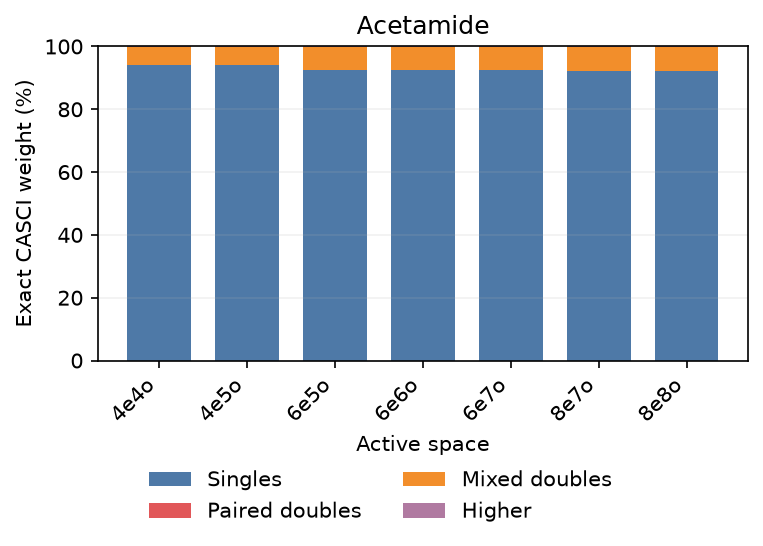
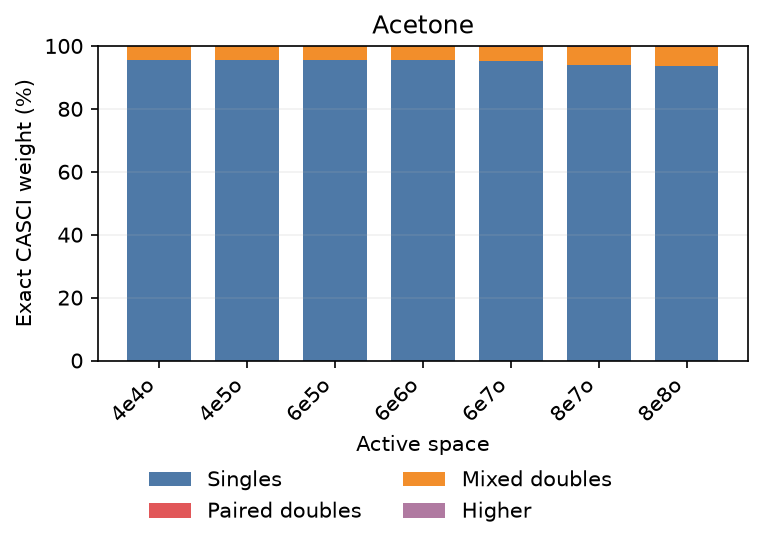
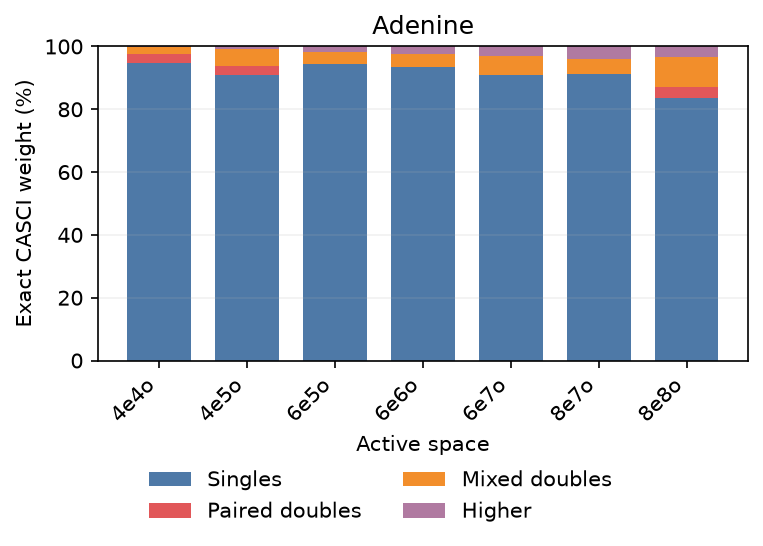
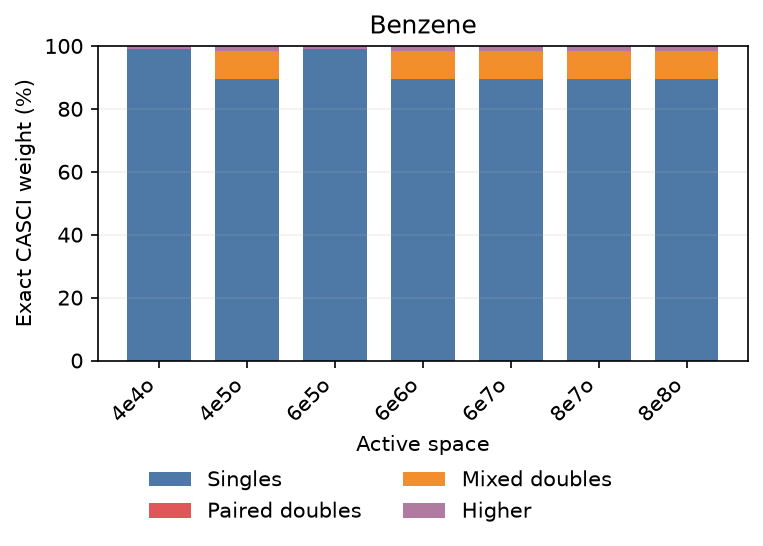
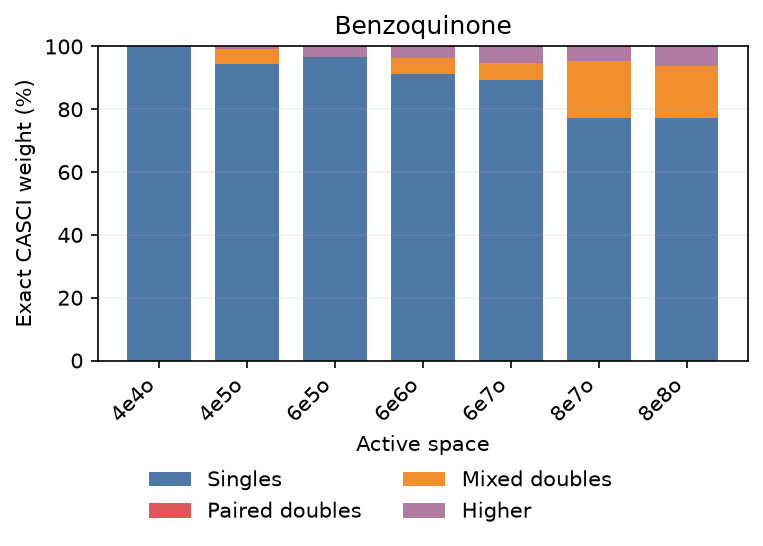
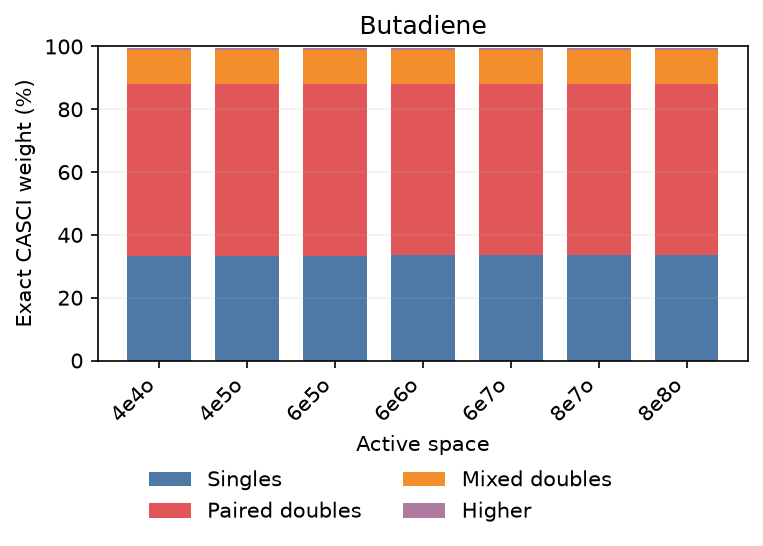
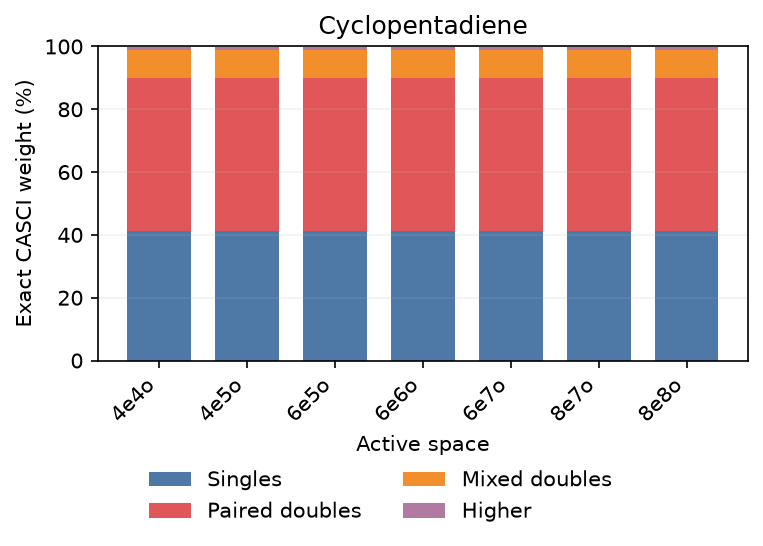
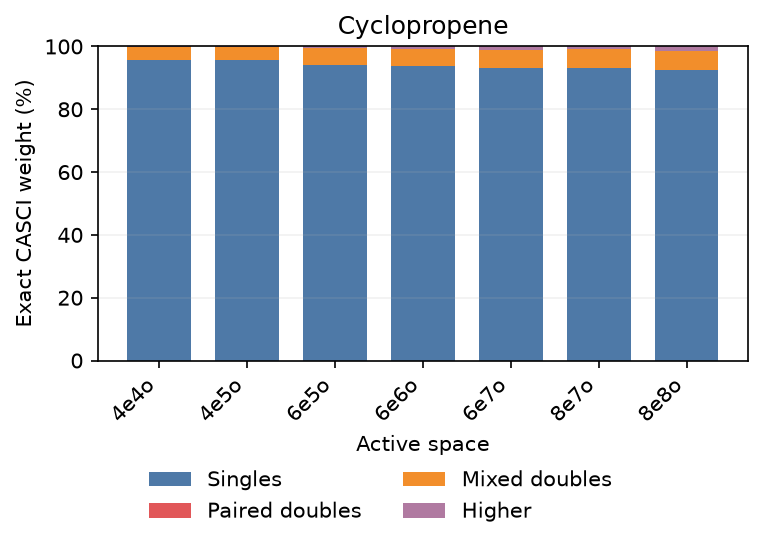
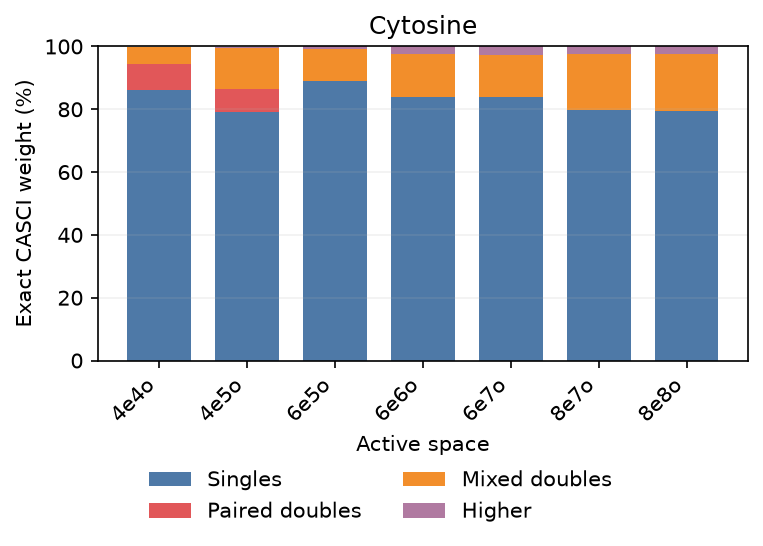
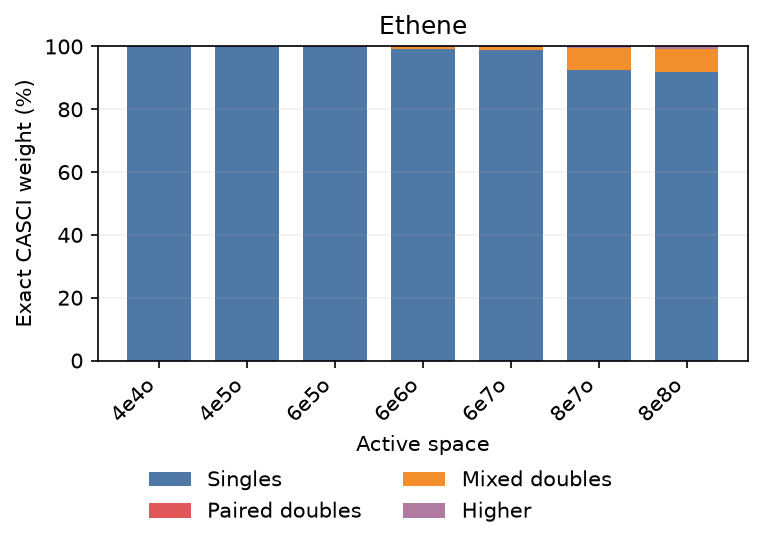
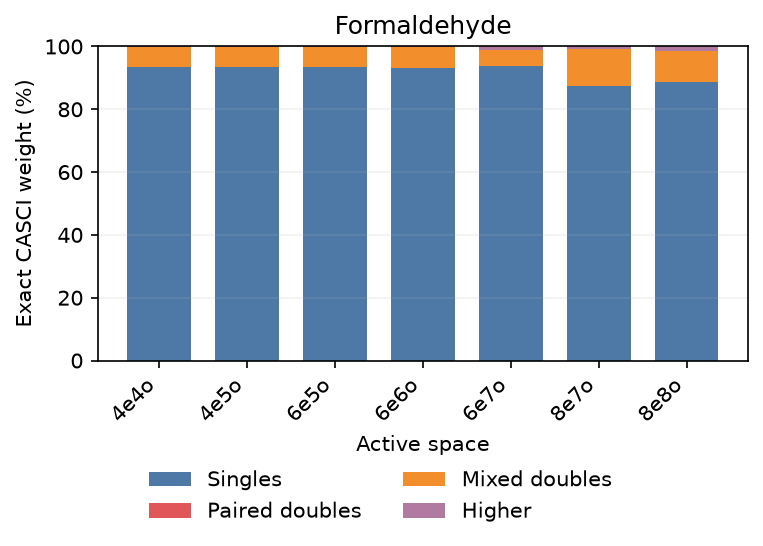
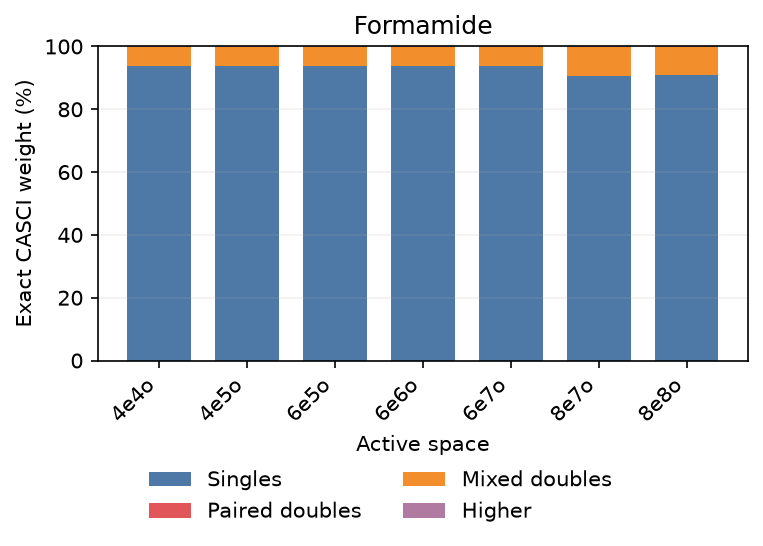
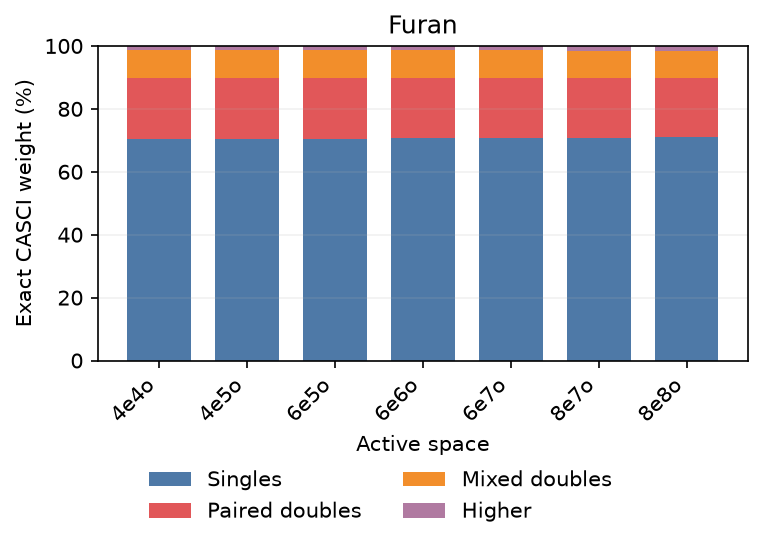
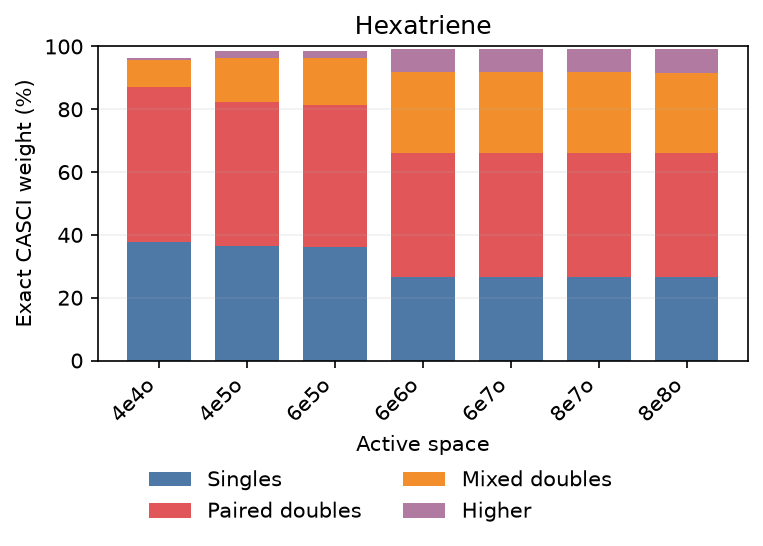
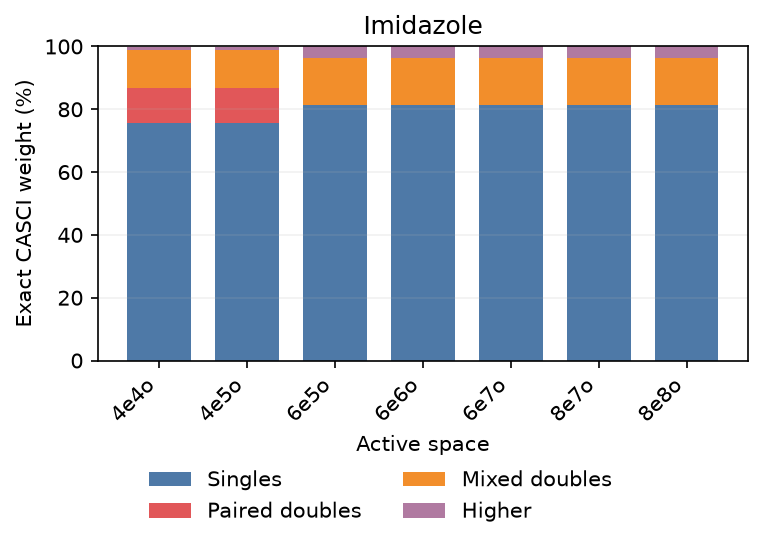
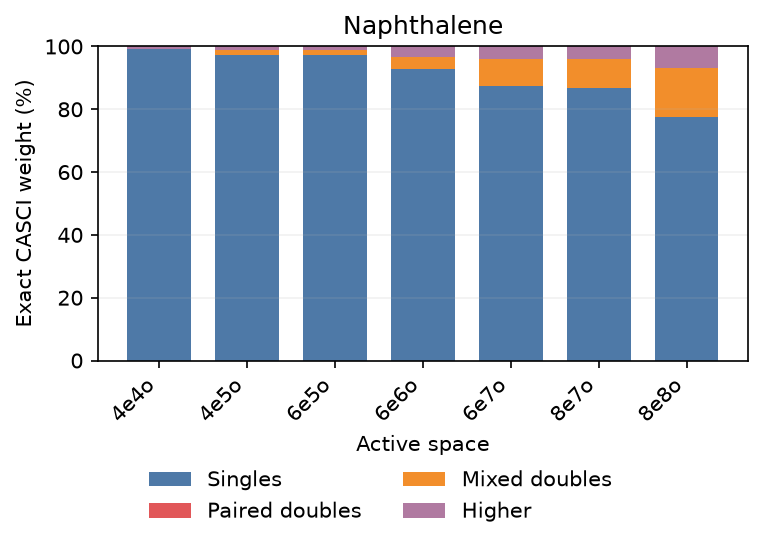
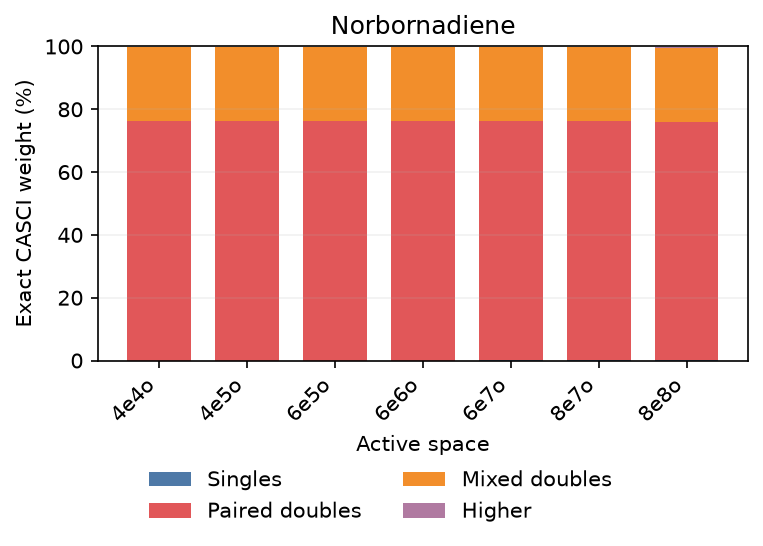
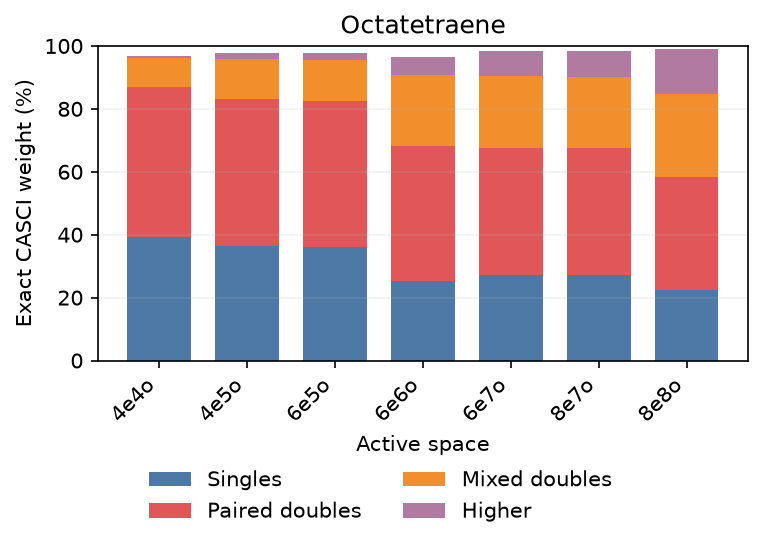
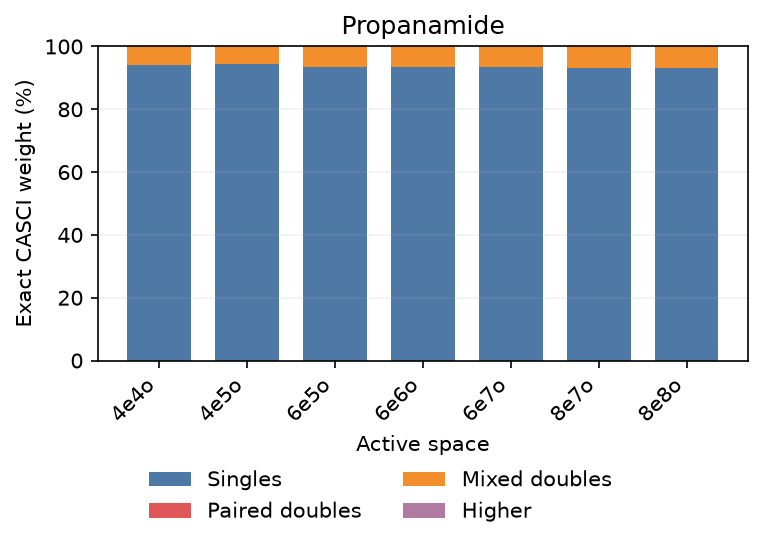
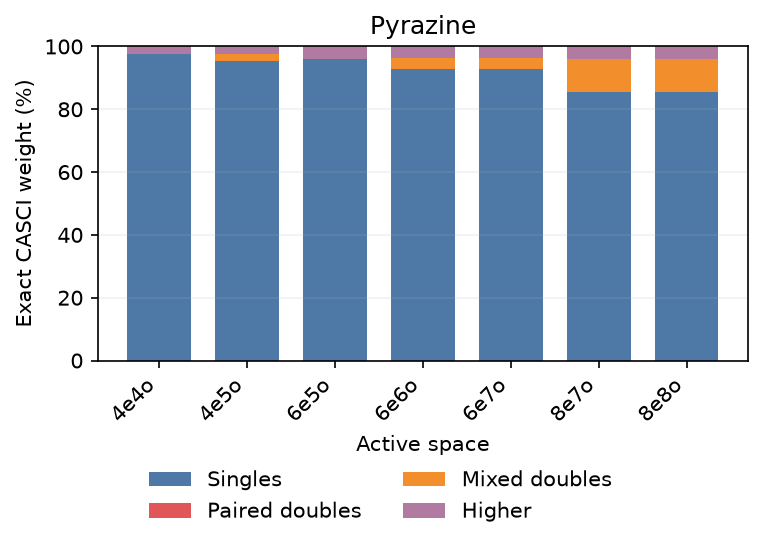
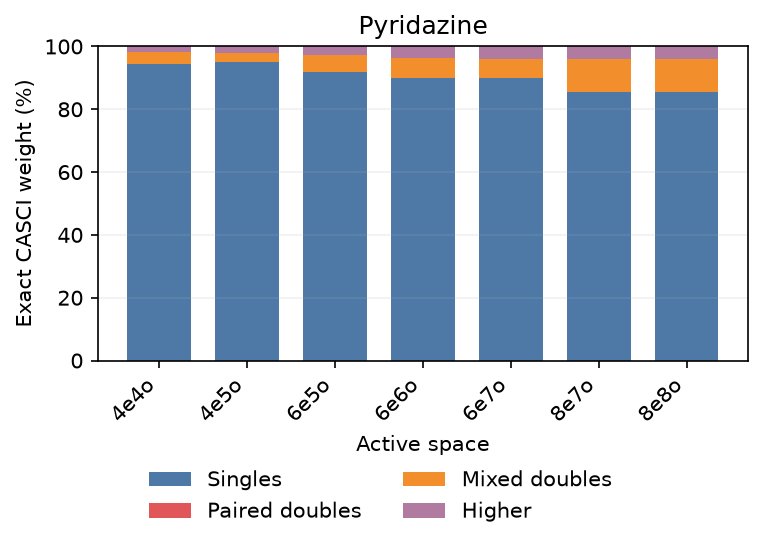
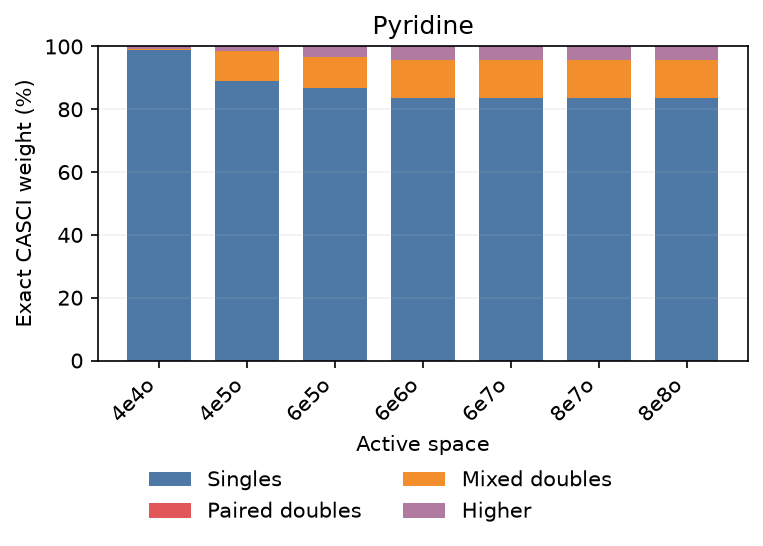
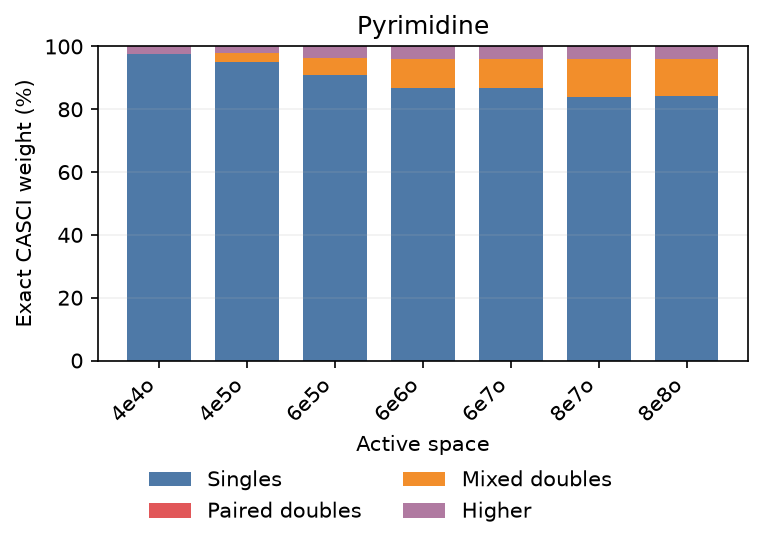
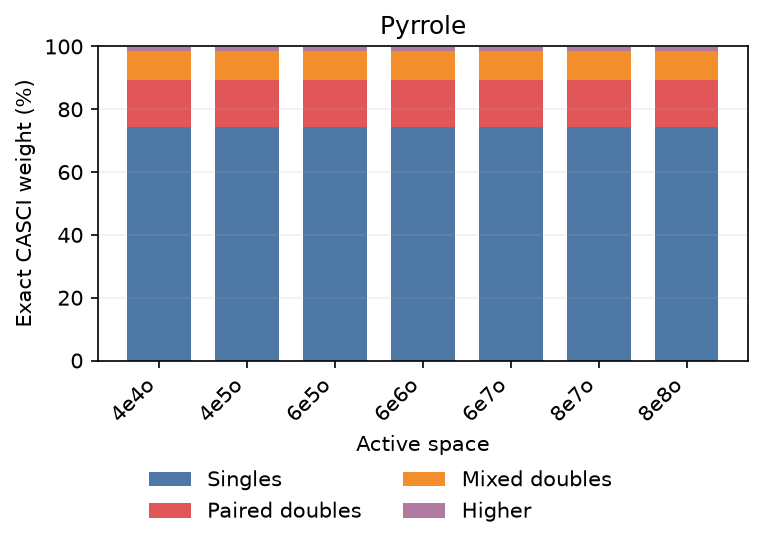
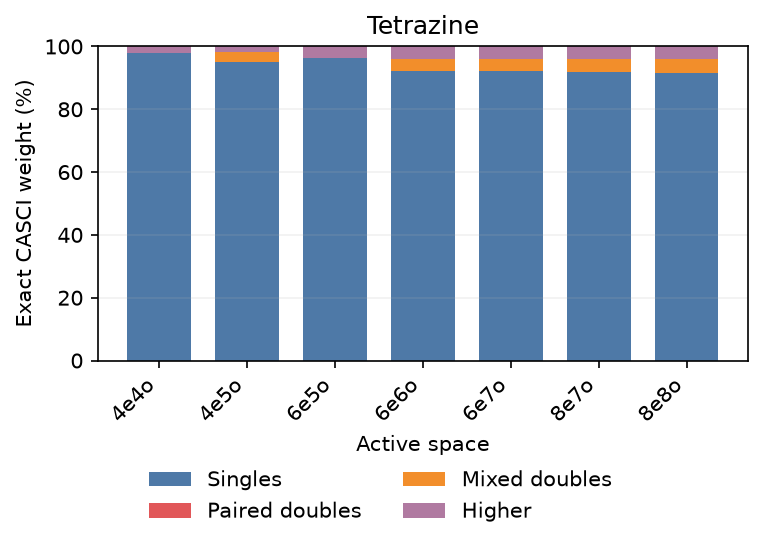
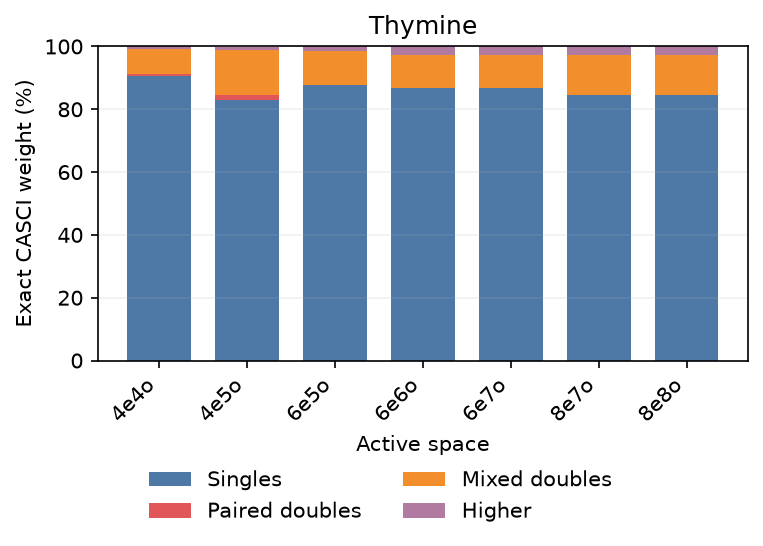
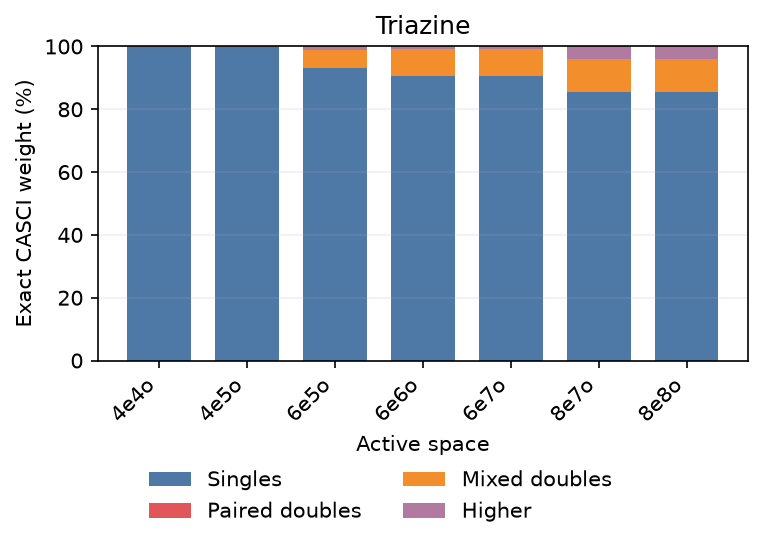
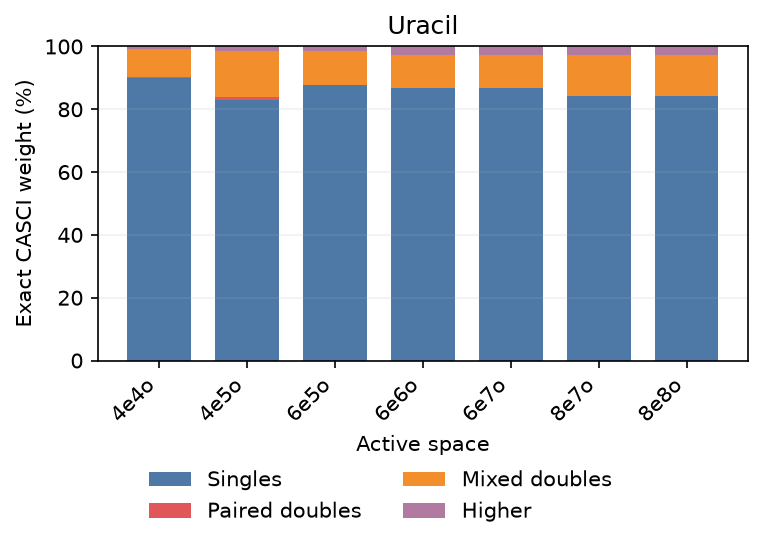

In [12]:
WINDOW_ACTIVE_SPACES = ["4e4o", "4e5o", "6e5o", "6e6o", "6e7o", "8e7o", "8e8o"]
s1_determinant_bases = {}


def get_s1_excitation_composition(pvec, active_space):
    if active_space not in s1_determinant_bases:
        num_electrons, num_orbitals = parse_active_space(active_space)
        hf_state = "11" * (num_electrons // 2) + "00" * (num_orbitals - num_electrons // 2)
        determinants = [
            format(index, f"0{2 * num_orbitals}b")
            for index in range(2 ** (2 * num_orbitals))
            if format(index, f"0{2 * num_orbitals}b").count("1") == num_electrons
        ]
        s1_determinant_bases[active_space] = hf_state, determinants

    hf_state, determinants = s1_determinant_bases[active_space]
    weights = np.abs(np.asarray(pvec, dtype=complex)) ** 2
    weights /= weights.sum()
    composition = dict.fromkeys(["reference", "singles", "paired_doubles", "mixed_doubles", "higher"], 0.0)

    for determinant, weight in zip(determinants, weights):
        holes = [index for index, (hf_bit, bit) in enumerate(zip(hf_state, determinant)) if hf_bit == "1" and bit == "0"]
        particles = [index for index, (hf_bit, bit) in enumerate(zip(hf_state, determinant)) if hf_bit == "0" and bit == "1"]

        if not holes:
            category = "reference"
        elif len(holes) == 1:
            category = "singles"
        elif len(holes) == 2:
            spatial_holes = [index // 2 for index in holes]
            spatial_particles = [index // 2 for index in particles]
            category = "paired_doubles" if len(set(spatial_holes)) == len(set(spatial_particles)) == 1 else "mixed_doubles"
        else:
            category = "higher"

        composition[category] += weight

    return {category: 100 * weight for category, weight in composition.items()}


singlet_rows = df_casci[df_casci["spin_type"] == "singlet"].set_index(["molecule", "active_space"])
composition_rows = []
for molecule in MOLECULE_NAMES:
    for active_space in WINDOW_ACTIVE_SPACES:
        composition = get_s1_excitation_composition(
            singlet_rows.loc[molecule, active_space]["casci_pvec"][1], active_space
        )
        composition_rows.append({"molecule": molecule, "active_space": active_space, **composition})

df_s1_active_space_composition = pd.DataFrame(composition_rows)
df_s1_active_space_composition["active_space"] = pd.Categorical(
    df_s1_active_space_composition["active_space"], WINDOW_ACTIVE_SPACES, ordered=True
)
df_s1_active_space_composition = df_s1_active_space_composition.sort_values(["molecule", "active_space"])

print(f"Prepared {len(df_s1_active_space_composition):,} exact-CASCI S1 composition records.")
orbital_window_composition_figures = []
for molecule in MOLECULE_NAMES:
    figure = plot_s1_casci_composition(df_s1_active_space_composition, molecule)
    save_figure(
        figure,
        "casci_doubles_weight/orbital_window_composition",
        f"casci_s1_composition_{molecule.lower().replace(' ', '_')}",
    )
    orbital_window_composition_figures.append(figure)
show_scrollable_figs(orbital_window_composition_figures)

## Exact CASCI Double-Excitation Weights


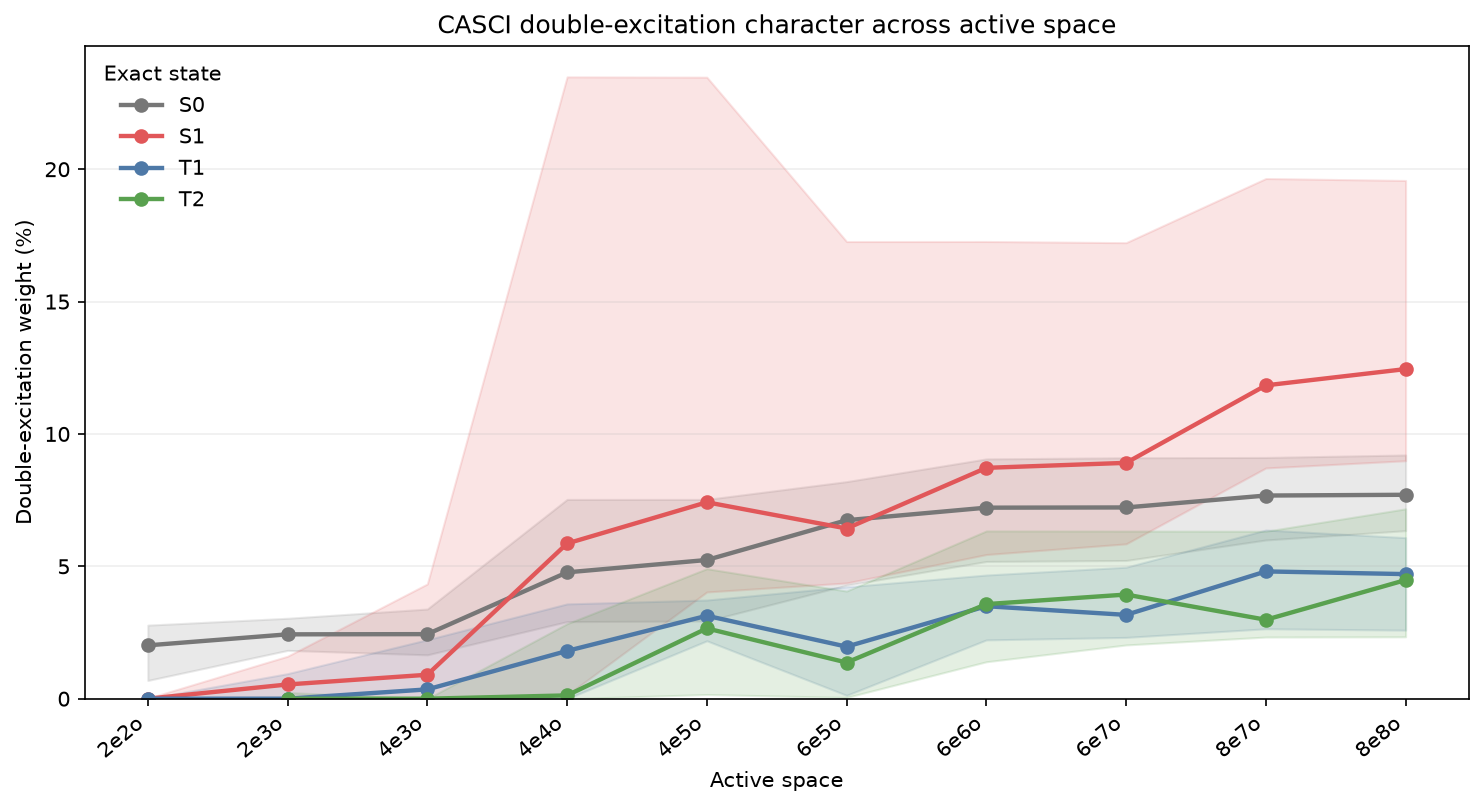

In [13]:
def get_low_state_double_weights(df_casci):
    state_roots = {"singlet": {"s0": 0, "s1": 1}, "triplet": {"t1": 0, "t2": 1}}
    records = []

    for _, row in df_casci.iterrows():
        num_electrons, num_orbitals = parse_active_space(row["active_space"])
        hf_state = "11" * (num_electrons // 2) + "00" * (num_orbitals - num_electrons // 2)

        for state, root in state_roots[row["spin_type"]].items():
            if root >= len(row["casci_pvec"]):
                continue

            sector_weights = [
                get_excitation_percentages(pvec, hf_state)[2]
                for pvec in np.atleast_2d(row["casci_pvec"][root])
            ]
            records.append({
                "molecule": row["molecule"],
                "active_space": row["active_space"],
                "state": state,
                "doubles": float(np.mean(sector_weights)),
            })

    return pd.DataFrame(records)


df_low_state_double_weights = get_low_state_double_weights(df_casci)
active_spaces = sorted(df_low_state_double_weights["active_space"].unique(), key=parse_active_space)
states = ["s0", "s1", "t1", "t2"]
double_weight_data = {
    active_space: {
        state: df_low_state_double_weights.loc[
            (df_low_state_double_weights["active_space"] == active_space)
            & (df_low_state_double_weights["state"] == state), "doubles"
        ].to_numpy()
        for state in states
    }
    for active_space in active_spaces
}

low_state_double_weight_figure = plot_low_state_double_weight_scaling(double_weight_data)
save_figure(
    low_state_double_weight_figure, "active_space_representability/casci_doubles_weight", "low_state_double_excitation_weight_scaling"
)
show_scrollable_figs([low_state_double_weight_figure])


In [14]:
# Mean and median exact double-excitation weights across the 28 molecules.
summary_states = ["s0", "s1", "t1", "t2"]
summary_active_spaces = sorted(df_low_state_double_weights["active_space"].unique(), key=parse_active_space)
df_double_weight_summary = (
    df_low_state_double_weights[df_low_state_double_weights["state"].isin(summary_states)]
    .groupby(["active_space", "state"])["doubles"]
    .agg(["mean", "median"]).unstack("state")
    .reindex(index=summary_active_spaces, columns=pd.MultiIndex.from_product(
        [["mean", "median"], summary_states], names=["Statistic", "State"]
    ))
)
display(df_double_weight_summary.style.format("{:.2f}", na_rep="Unavailable").set_caption(
    "Exact CASCI double-excitation weight (%): mean and median across 28 molecules"
))


In [15]:
# Mean exact S1/S2 composition for the five persistent root-skipping cases.
five_special_molecules = ["Butadiene", "Cyclopentadiene", "Furan", "Norbornadiene", "Pyrrole"]
special_active_spaces = ["4e4o", "4e5o", "6e5o", "6e6o", "6e7o", "8e7o", "8e8o"]
special_casci_rows = df_casci[
    df_casci["molecule"].isin(five_special_molecules)
    & df_casci["active_space"].isin(special_active_spaces)
    & (df_casci["spin_type"] == "singlet")
]
special_composition_records = []
for _, row in special_casci_rows.iterrows():
    num_electrons, num_orbitals = parse_active_space(row["active_space"])
    hf_state = "11" * (num_electrons // 2) + "00" * (num_orbitals - num_electrons // 2)
    record = {"molecule": row["molecule"], "active_space": row["active_space"]}
    for state, root in (("s1", 1), ("s2", 2)):
        weights = get_excitation_percentages(row["casci_pvec"][root], hf_state)
        record[f"{state}_singles"] = weights[1]
        record[f"{state}_doubles"] = weights[2]
    special_composition_records.append(record)

df_special_s1_s2_composition = pd.DataFrame(special_composition_records)
composition_columns = ["s1_singles", "s1_doubles", "s2_singles", "s2_doubles"]
df_special_s1_s2_summary = (
    df_special_s1_s2_composition.groupby("active_space")[composition_columns]
    .mean().reindex(special_active_spaces)
)
display(df_special_s1_s2_summary.style.format("{:.2f}").set_caption(
    "Exact CASCI S1/S2 composition (%): mean across the five root-skipping molecules"
))


,s1_singles,s1_doubles,s2_singles,s2_doubles
active_space,,,,
4e4o,43.87,55.19,95.82,3.31
4e5o,43.88,55.18,95.72,3.43
6e5o,43.88,55.18,95.49,3.69
6e6o,43.98,55.03,95.28,3.84
6e7o,44.04,54.89,94.85,4.23
8e7o,44.03,54.92,94.89,4.18
8e8o,44.12,54.70,94.41,4.55


### Orbital-window examples: Benzene and Imidazole


In [16]:
# Exact S1 composition and index-matched UCCSD errors for orbital-window examples.
orbital_example_molecules = ["Benzene", "Imidazole"]
orbital_example_errors = pd.read_csv(PROCESSED_DATAFRAMES_DIR / "uccsd_low_lying_state_errors.csv")
df_orbital_window_examples = df_s1_active_space_composition[
    df_s1_active_space_composition["molecule"].isin(orbital_example_molecules)
].copy()
df_orbital_window_examples["doubles"] = (
    df_orbital_window_examples["paired_doubles"] + df_orbital_window_examples["mixed_doubles"]
)
df_orbital_window_examples = df_orbital_window_examples[
    ["molecule", "active_space", "singles", "doubles", "higher"]
].merge(
    orbital_example_errors[["molecule", "active_space", "s1"]].rename(columns={"s1": "error_mHa"}),
    on=["molecule", "active_space"], validate="one_to_one"
)

for molecule in orbital_example_molecules:
    table = df_orbital_window_examples[
        df_orbital_window_examples["molecule"] == molecule
    ].drop(columns="molecule").set_index("active_space").reindex(WINDOW_ACTIVE_SPACES)
    display(table.style.format({
        "singles": "{:.2f}", "doubles": "{:.2f}", "higher": "{:.2f}", "error_mHa": "{:.6g}"
    }).set_caption(f"{molecule}: exact CASCI S1 weights (%) and UCCSD S1 error (mHa)"))


,singles,doubles,higher,error_mHa
active_space,,,,
4e4o,99.16,0.00,0.84,1.68274e-06
4e5o,89.39,9.09,1.52,70.8845
6e5o,99.15,0.00,0.85,0.000585507
6e6o,89.39,9.09,1.52,70.9018
6e7o,89.37,9.09,1.54,70.9121
8e7o,89.38,9.09,1.53,70.8955
8e8o,89.35,9.09,1.57,70.9276


,singles,doubles,higher,error_mHa
active_space,,,,
4e4o,75.58,23.23,1.16,91.2952
4e5o,75.59,23.22,1.17,91.2865
6e5o,81.38,14.94,3.67,20.5265
6e6o,81.37,14.95,3.68,18.1754
6e7o,81.40,14.92,3.69,18.1032
8e7o,81.34,14.98,3.68,18.1174
8e8o,81.36,14.94,3.70,18.6949
